# Euler Milstein comparison
## Plots and Tables

Some Initialization

In [1]:
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.04             # Risk-free rate
sigma = 2.0          # Volatility
gamma = 0.9          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles

## Option price vs Step size

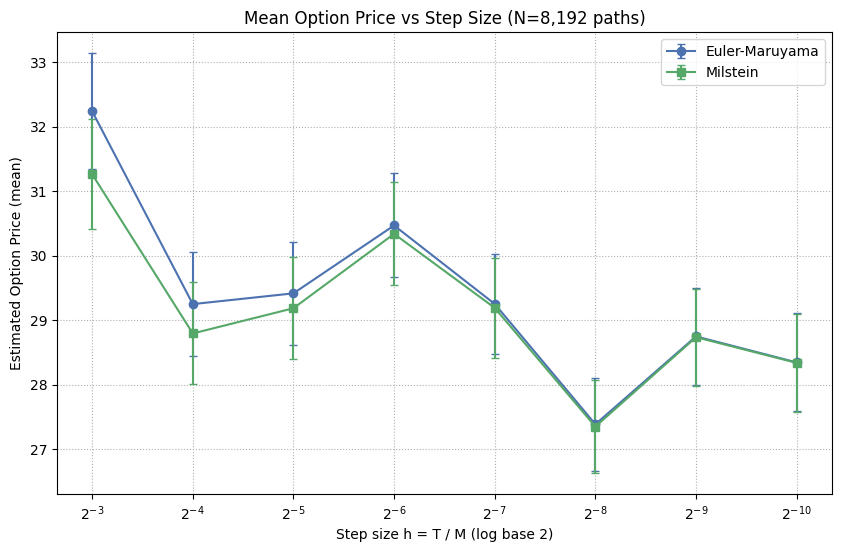

In [5]:
# Mean option price vs step size h: Euler-Maruyama vs Milstein
# Uses existing `sim`, `N`, `np`, `plt`. Restores sim.M after the experiment.

orig_M = sim.M
M_values = [8, 16, 32, 64, 128, 256, 512, 1024]   # different time-step resolutions
means_euler = []
ses_euler = []
means_milstein = []
ses_milstein = []
times_euler = []
times_milstein = []

rng = np.random.default_rng(12345)  # fixed seed for reproducibility

for M_current in M_values:
    sim.M = M_current
    # draw standard normals: shape (N, M)
    Z = rng.standard_normal(size=(N, sim.M))


    # Euler-Maruyama using the library's payoff-from-Z helper (per-path payoffs -> mean & SE)
    Starteuler = time.perf_counter()
    payoffs_e = sim.price_asian_option_from_Z_raw(Z, euler=True)   # array of length N (discounted payoffs)
    mean_e = float(payoffs_e.mean())
    se_e = float(payoffs_e.std(ddof=1) / (N**0.5))
    Endeuler = time.perf_counter()

    means_euler.append(mean_e)
    ses_euler.append(se_e)
    times_euler.append(Endeuler - Starteuler)

    # Milstein using the same Z (CRN between schemes)
    Startmilstein = time.perf_counter()
    payoffs_m = sim.price_asian_option_from_Z_raw(Z, euler=False)
    mean_m = float(payoffs_m.mean())
    se_m = float(payoffs_m.std(ddof=1) / (N**0.5))
    Endmilstein = time.perf_counter()
    
    means_milstein.append(mean_m)
    ses_milstein.append(se_m)
    times_milstein.append(Endmilstein - Startmilstein)

# restore original M
sim.M = orig_M

h_values = [sim.T / M for M in M_values]

plt.figure(figsize=(10,6))
plt.errorbar(h_values, means_euler, yerr=ses_euler, fmt='o-', label='Euler-Maruyama', capsize=3, color='#4C72B0')
plt.errorbar(h_values, means_milstein, yerr=ses_milstein, fmt='s-', label='Milstein', capsize=3, color='#55A868')
plt.xscale('log', base=2)
plt.gca().invert_xaxis()  # smaller h (finer grid) to the right
plt.xlabel('Step size h = T / M (log base 2)')
plt.ylabel('Estimated Option Price (mean)')
plt.title(f'Mean Option Price vs Step Size (N={N:,} paths)')
plt.legend()
plt.grid(True, which='both', ls=':')
os.makedirs('Graphs', exist_ok=True)
plt.savefig(os.path.join('Graphs', 'Euler_vs_Milstein.png'), bbox_inches='tight')
plt.show()


In [6]:
import pandas as pd

# Build summary table
df = pd.DataFrame({
    'M': M_values,
    'h': h_values,
    'Mean_Euler': means_euler,
    'SE_Euler': ses_euler,
    'CI_Euler_L': [m - 1.96*s for m, s in zip(means_euler, ses_euler)],
    'CI_Euler_U': [m + 1.96*s for m, s in zip(means_euler, ses_euler)],
    'Time_Euler': times_euler,
    'Mean_Milstein': means_milstein,
    'SE_Milstein': ses_milstein,
    'CI_Mil_L': [m - 1.96*s for m, s in zip(means_milstein, ses_milstein)],
    'CI_Mil_U': [m + 1.96*s for m, s in zip(means_milstein, ses_milstein)],
    'CI_Width_Euler': [2*1.96*s for s in ses_euler],
    'CI_Width_Milstein': [2*1.96*s for s in ses_milstein],
    'Time_Milstein': times_milstein
})

# Helpful diagnostics
df['Mean_Diff (Milstein - Euler)'] = df['Mean_Milstein'] - df['Mean_Euler']
df['SE_Ratio (Mil/Eu)'] = df['SE_Milstein'] / df['SE_Euler']
df['Time_diff (Mil - Eu)'] = df['Time_Milstein'] - df['Time_Euler']

# Pretty print
pd.options.display.float_format = '{:.6f}'.format
df_display = df[['M', 'Mean_Euler', 'SE_Euler', 'CI_Width_Euler',
                 'Mean_Milstein', 'SE_Milstein', 'CI_Width_Milstein',
                 'SE_Ratio (Mil/Eu)', 'Time_Euler', 'Time_Milstein','Time_diff (Mil - Eu)']]

# make column names tighter in an extra snippet
# 1) remove any literal "\_" escapes
df.columns = [c.replace('\\_', '_') for c in df.columns]

# 2) map to shorter names
short_map = {
    'Mean_Euler': '$Mean_{Euler}$',
    'SE_Euler': '$SE_{Euler}$',
    'CI_Width_Euler': '$CIw_{Euler}$',
    'Time_Euler': '$Time_{Euler}$',
    'Mean_Milstein': '$Mean_{Milstein}$',
    'SE_Milstein': '$SE_{Milstein}$',
    'CI_Width_Milstein': '$CIw_{Milstein}$',
    'Time_Milstein': '$Time_{Milstein}$',
    'SE_Ratio (Mil/Eu)': '$SE_{ratio}$',
    'Time_diff (Mil - Eu)': '$Time_{diff}$'
    }
df.rename(columns=short_map, inplace=True)

# 3) refresh the display frame to use the new short names
df_display = df[['M', '$Mean_{Euler}$', '$SE_{Euler}$', '$CIw_{Euler}$','$Time_{Euler}$', '$Mean_{Milstein}$', '$SE_{Milstein}$', '$CIw_{Milstein}$', '$Time_{Milstein}$','$SE_{ratio}$', '$Time_{diff}$']]
display(df_display)


,M,$Mean_{Euler}$,$SE_{Euler}$,$CIw_{Euler}$,$Time_{Euler}$,$Mean_{Milstein}$,$SE_{Milstein}$,$CIw_{Milstein}$,$Time_{Milstein}$,$SE_{ratio}$,$Time_{diff}$
0,8,32.240540,0.901112,3.532360,0.006166,31.263210,0.853162,3.344394,0.004492,0.946787,-0.001674
1,16,29.248483,0.811703,3.181875,0.008713,28.793120,0.791364,3.102148,0.007329,0.974943,-0.001384
2,32,29.415190,0.799078,3.132387,0.014888,29.184373,0.788645,3.091489,0.014296,0.986944,-0.000592
3,64,30.468492,0.806349,3.160888,0.028777,30.338026,0.801006,3.139944,0.029351,0.993374,0.000574
4,128,29.250566,0.772471,3.028085,0.061619,29.189534,0.769869,3.017886,0.060146,0.996632,-0.001474
5,256,27.384152,0.723063,2.834408,0.129272,27.348243,0.721619,2.828745,0.118843,0.998002,-0.010429
6,512,28.747272,0.755339,2.960929,0.288837,28.734874,0.754789,2.958775,0.277627,0.999272,-0.011210
7,1024,28.343556,0.760178,2.979896,0.586742,28.337063,0.759923,2.978898,0.546929,0.999665,-0.039813


In [7]:
# simple export (what you had)
# simple export (what you had)
os.makedirs('Tables', exist_ok=True)
out_path = os.path.join('Tables', 'Euler_Milstein_Comparison.tex')
df_display.to_latex(out_path, index=False, float_format="%.4f")
print(f"Saved LaTeX table to {out_path}")

Saved LaTeX table to Tables/Euler_Milstein_Comparison.tex
